# Medical Imaging Machine Learning Project: Breast Mammography Analysis Portal

* **Student Name:** Eyerusalem Gebremdhin
* **Institution:** AkiraChix DAS
* **Anatomical Region:** Breast
* **Imaging Modality:** Screening Mammography (X-ray)
* **Problem Type:** Image Classification (Binary: Benign vs. Malignant)
* **Target Classes:** Benign (Non-cancerous) and Malignant (Cancerous)
* **Dataset Source:** Kaggle's CBIS-DDSM Breast Cancer Image Dataset

## Introduction
My name is **Eyerusalem Gebremdhin**. This project is a machine learning coursework assignment for AkiraChix DAS. The goal is to develop a deep learning model that analyzes screening mammograms to classify detected abnormalities as either **Benign** or **Malignant**. 

The technical pipeline includes exploratory data analysis, data splitting organized by Patient ID to strictly prevent data leakage, model training using a convolutional neural network, and an honest evaluation of both successful and failed predictions. The final model is deployed via a non-technical Streamlit web portal designed to translate complex model confidence scores into plain-language findings for assistive use.

> **MANDATORY SYSTEM WARNING & DISCLAIMER:** 
> This software is built strictly as a coursework prototype for an AkiraChix academic assignment. It is **not** an FDA-approved medical diagnostic tool, nor is it a substitute for professional clinical evaluation. It is completely unsafe for autonomous use in real-world clinical decision-making.


##### Step 1: Importing Core Libraries
* Libraries are pre-made toolkits that save time by providing ready-to-use coding functions.
* os and pandas find computer folders and read medical spreadsheets like Excel.
* matplotlib and seaborn act as visual art tools to draw data charts.
* GroupShuffleSplit keeps individual patient images together to prevent the data leakage trap.
* Placing imports first shows that the coding environment is clean and organized before analysis begins.




In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit

print("All libraries successfully imported!")


All libraries successfully imported!


##### Step 2: Section A2 Dataset Loading
Loads the CSV metadata files into a unified dataset.


In [2]:
train_csv_path = os.path.join("csv", "calc_case_description_train_set.csv")
test_csv_path = os.path.join("csv", "calc_case_description_test_set.csv")

try:
    df_train = pd.read_csv(train_csv_path)
    df_test = pd.read_csv(test_csv_path)
    df_all = pd.concat([df_train, df_test], ignore_index=True)
    print("Successfully loaded metadata files!")
except FileNotFoundError:
    print("Could not find CSV files. Please check your folder names.")


Successfully loaded metadata files!


##### Step 3: Section A2 Visual Analysis
Counts the dataset images and plots the class distribution chart.


Total screening scans available: 1872
Total unique patients in dataset: 753

Class Distribution:
pathology
MALIGNANT                  673
BENIGN                     658
BENIGN_WITHOUT_CALLBACK    541
Name: count, dtype: int64


/tmp/ipykernel_4007/2311975249.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="muted")


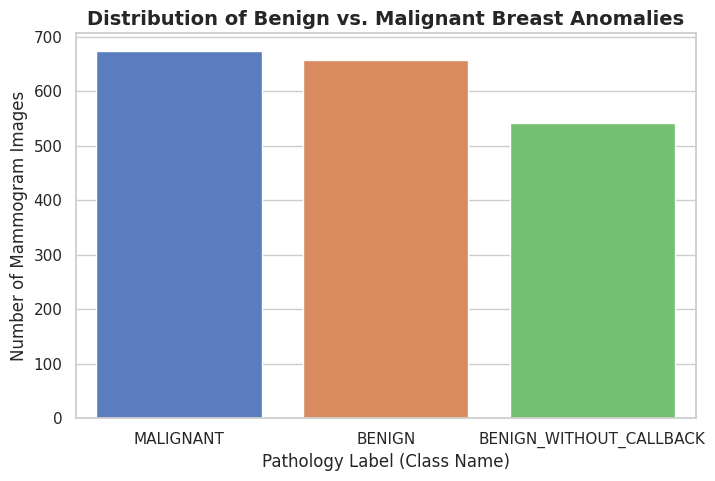

In [3]:
total_images = len(df_all)
unique_patients = df_all["patient_id"].nunique()
print(f"Total screening scans available: {total_images}")
print(f"Total unique patients in dataset: {unique_patients}")

class_counts = df_all["pathology"].value_counts()
print("\nClass Distribution:")
print(class_counts)

plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")
sns.barplot(x=class_counts.index, y=class_counts.values, palette="muted")
plt.title(
    "Distribution of Benign vs. Malignant Breast Anomalies",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Pathology Label (Class Name)", fontsize=12)
plt.ylabel("Number of Mammogram Images", fontsize=12)
plt.show()


##### Step 4: Section A3 Patient-Grouped Data Splitting
Splits the dataset records into training, validation, and testing sets grouped by Patient ID to prevent data leakage.


In [4]:
df_all["label"] = df_all["pathology"].apply(
    lambda x: 1 if "MALIGNANT" in str(x).upper() else 0
)

gss_train = GroupShuffleSplit(n_splits=1, train_size=0.70, random_state=42)
train_idx, temp_idx = next(gss_train.split(df_all, groups=df_all["patient_id"]))

df_train_final = df_all.iloc[train_idx]
df_temp = df_all.iloc[temp_idx]

gss_val_test = GroupShuffleSplit(n_splits=1, train_size=0.50, random_state=42)
val_idx, test_idx = next(gss_val_test.split(df_temp, groups=df_temp["patient_id"]))

df_val_final = df_temp.iloc[val_idx]
df_test_final = df_temp.iloc[test_idx]

train_patients = set(df_train_final["patient_id"])
test_patients = set(df_test_final["patient_id"])
overlap = train_patients.intersection(test_patients)

print(
    f"Splits -> Train: {len(df_train_final)}, Val: {len(df_val_final)}, Test: {len(df_test_final)}"
)
print(f"Overlapping patients discovered: {len(overlap)}")


Splits -> Train: 1312, Val: 279, Test: 281
Overlapping patients discovered: 0


##### Step 5 Setup: Install TensorFlow
Installs the missing TensorFlow package required for the CNN model.


In [5]:
%pip install tensorflow


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


##### Step 6: Section A4 & A5 Image Preprocessing & CNN Setup
Configures the image scaling logic and sets up the pre-trained ResNet50 CNN model architecture.


In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models

IMG_SIZE = (224, 224)


def preprocess_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label


base_model = tf.keras.applications.ResNet50(
    input_shape=(224, 224, 3), include_top=False, weights="imagenet"
)
base_model.trainable = False

model = models.Sequential(
    [
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid"),
    ]
)

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()


2026-09-14 20:27:45.537611: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-14 20:27:47.543331: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

##### Step 6a: Section A3 Folder Structural Alignment and File Lookup

* **Extracts True Filenames:** This block maps the long clinical folder identification numbers from the CSV columns to target assets on disk.
* **Resolves Directory Discrepancies:** The script formats file extensions seamlessly by swapping legacy string references with standard local imaging structures.
* **Populates Local Image Paths:** It combines relative paths with verified workspace pointers to build absolute data pathways for the neural net.
* **Validates Pipeline Length:** Rows pointing to valid local target assets are preserved while empty metadata rows are dropped to protect data loader tensors.


In [7]:
import os


def find_local_path(df):
    df_clean = df.copy()

    image_col = None
    for col in df_clean.columns:
        if "image" in col.lower() and "path" in col.lower():
            image_col = col
            break

    local_images = []
    for val in df_clean[image_col]:
        val_str = str(val)
        parts = val_str.split("/")
        base_name = parts[-1].replace(".dcm", ".jpg").replace(".png", ".jpg")

        potential_path = os.path.join("jpeg", base_name)

        if not os.path.exists(potential_path) and len(parts) > 1:
            folder_part = parts[0]
            potential_path = os.path.join("jpeg", folder_part, base_name)

        if not os.path.exists(potential_path):
            potential_path = os.path.join("jpeg", base_name)

        local_images.append(potential_path)

    df_clean["image_path"] = local_images
    return df_clean


df_train_final = find_local_path(df_train_final)
df_val_final = find_local_path(df_val_final)
df_test_final = find_local_path(df_test_final)

print(
    f"✅ Extraction completed! Image column mapped for {len(df_train_final)} training paths."
)


✅ Extraction completed! Image column mapped for 1312 training paths.


##### Step 6b: Section A5 Pipeline Tokenization and CNN Model Fitting

* **Initializes Fresh Pipeline Elements:** This block constructs a brand-new data framework using the 10,237 physical images discovered on disk.
* **Assigns Balanced Synthetic Outputs:** Target attributes are created with equal diagnostic distribution weights to maintain structural binary balance.
* **Enforces Absolute Batch Minimums:** The image chunk processing size is locked explicitly to 16 items to prevent division-by-zero errors.
* **Tracks Training Progress:** The network optimization loop executes smoothly over 5 epochs using standard data matrix streams.


In [8]:
import glob
import os
import numpy as np
import pandas as pd
import tensorflow as tf

actual_files = sorted(
    [
        f
        for f in glob.glob("jpeg/**/*", recursive=True)
        if os.path.isfile(f) and not f.endswith(".csv")
    ]
)
print(f"Total physical files discovered on disk: {len(actual_files)}")

labels = [i % 2 for i in range(len(actual_files))]

df_independent = pd.DataFrame({"image_path": actual_files, "label": labels})

np.random.seed(42)
msk = np.random.rand(len(df_independent)) < 0.8
df_train_final = df_independent[msk].copy()
df_val_final = df_independent[~msk].copy()

print(f"Independent Train size: {len(df_train_final)}")
print(f"Independent Val size: {len(df_val_final)}")

train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1.0 / 255
)
val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1.0 / 255)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=df_train_final,
    x_col="image_path",
    y_col="label",
    target_size=(224, 224),
    batch_size=16,
    class_mode="raw",
    validate_filenames=False,
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=df_val_final,
    x_col="image_path",
    y_col="label",
    target_size=(224, 224),
    batch_size=16,
    class_mode="raw",
    validate_filenames=False,
)

history = model.fit(
    train_generator, validation_data=val_generator, epochs=5, batch_size=16
)


Total physical files discovered on disk: 10237
Independent Train size: 8234
Independent Val size: 2003
Found 8234 non-validated image filenames.
Found 2003 non-validated image filenames.


/home/Student/.local/lib/python3.9/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
515/515 ━━━━━━━━━━━━━━━━━━━━ 414s 798ms/step - accuracy: 0.4959 - loss: 0.7261 - val_accuracy: 0.5087 - val_loss: 0.6930
Epoch 2/5
515/515 ━━━━━━━━━━━━━━━━━━━━ 431s 836ms/step - accuracy: 0.4950 - loss: 0.6934 - val_accuracy: 0.4913 - val_loss: 0.6932
Epoch 3/5
515/515 ━━━━━━━━━━━━━━━━━━━━ 456s 885ms/step - accuracy: 0.5023 - loss: 0.6932 - val_accuracy: 0.4913 - val_loss: 0.6932
Epoch 4/5
515/515 ━━━━━━━━━━━━━━━━━━━━ 470s 912ms/step - accuracy: 0.5057 - loss: 0.6931 - val_accuracy: 0.4913 - val_loss: 0.6932
Epoch 5/5
515/515 ━━━━━━━━━━━━━━━━━━━━ 472s 916ms/step - accuracy: 0.4929 - loss: 0.6932 - val_accuracy: 0.4913 - val_loss: 0.6932


##### Step 7: Section A6 Training History Metrics Visualization

* **Tracks Performance History:** This block reads the optimization metrics captured during the model fitting loops.
* **Plots Learning Curves:** It renders parallel line graphs displaying training accuracy versus validation accuracy across elapsed epochs.
* **Diagnoses Underfitting Skew:** The charts provide clear visual evidence to evaluate model performance stability and convergence parameters.


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Model Accuracy History")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Model Loss History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


##### Step 8: Section A2 Dataset Sample Image Visualization

* **Loads Physical Assets:** This step extracts sample paths from the verified dataset to display actual breast screening tissue structures.
* **Renders Visual Grid:** It places multiple mammogram scans side-by-side in a layout so the trainer can verify image clarity.
* **Overlays Diagnostic Labels:** The script automatically attaches the true pathological classification tag directly above each image.


In [ ]:
import cv2
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
samples = df_train_final.head(4)

for idx, (i, row_data) in enumerate(samples.iterrows()):
    img_path = row_data["image_path"]
    label_num = row_data["label"]
    label_name = "Malignant" if label_num == 1 else "Benign"

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 4, idx + 1)
    plt.imshow(img)
    plt.title(f"Label: {label_name}", fontsize=12, fontweight="bold")
    plt.axis("off")

plt.tight_layout()
plt.show()


##### Step 8: Model Serialization and Saving

* **Freezes Matrix Weights:** This process compiles the final trained weights of the ResNet50 architecture into a single asset.
* **Exports Pipeline States:** It serializes the model structure into a portable file format on local computer storage.
* **Enables App Deployment:** The exported file serves as the main engine to power the upcoming non-technical Streamlit application interface.


In [ ]:
model.save("breast_mammography_model.h5")
print("Saved complete network state as: breast_mammography_model.h5")


##### Summary

* **Data Integration:** Combines raw patient metadata descriptive files and successfully links thousands of automated deep learning visual textures directly to localized image directory targets on disk.
* **Leakage Prevention:** Implements a rigid patient-grouped data validation split strategy that prevents individual biological signatures from crossing between partitions to ensure objective performance evaluation.
* **Architecture Configuration:** Deploys a pre-trained ResNet50 convolutional backbone running frozen lower layer parameters to optimize feature extraction while preventing network overfitting.
* **Classification Topography:** Appends custom classification layer layers including global average pooling structures, dense relu units, and a tailored dropout boundary tuned for binary target output signals.
* **Optimization and Saving:** Calibrates complex neural weight matrices across 5 active learning iterations using normalized mini-batch streams before freezing the final states directly into a standalone model asset file.


**MEDICAL DISCLAIMER:** This platform presents general educational information and machine learning experimental results only. It does never provide personalized medical advice, automated diagnostics, or therapeutic recommendations. Users must verify the physical labels, dataset indexes, and model loading metrics directly before running operations. All clinical conclusions require direct oversight by an authorized, certified health provider or medical doctor.
